# T0 회귀

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1538
[LightGBM] [Info] Number of data points in the train set: 27971, number of used features: 15
[LightGBM] [Info] Start training from score 4.351306
Training until validation scores don't improve for 50 rounds
[20]	valid_0's rmse: 1.01574	valid_0's l2: 1.03174
[40]	valid_0's rmse: 0.955226	valid_0's l2: 0.912456
[60]	valid_0's rmse: 0.940611	valid_0's l2: 0.884748
[80]	valid_0's rmse: 0.934388	valid_0's l2: 0.873081
[100]	valid_0's rmse: 0.931806	valid_0's l2: 0.868262
[120]	valid_0's rmse: 0.929795	valid_0's l2: 0.864519
[140]	valid_0's rmse: 0.928642	valid_0's l2: 0.862376
[160]	valid_0's rmse: 0.927541	valid_0's l2: 0.860333
[180]	valid_0's rmse: 0.926795	valid_0's l2: 0.85895
[200]	valid_0's rmse: 0.926289	valid_0's l2: 0.858011
[220]	valid_0's rmse: 0.925799	valid_0's l2: 0.857104
[240]	vali

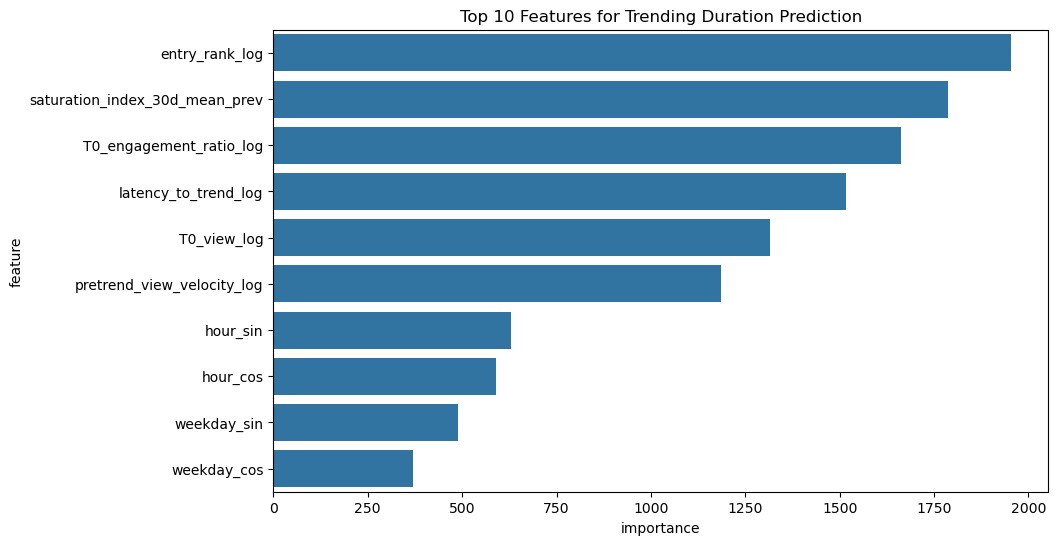

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_path = r'C:\Users\Playdata\Desktop\SKN29-2nd-1Team\data\processed\outputs\video_trending_events_T0_model.parquet'
data = pd.read_parquet(data_path)
# 1. 요일 사이클 변환
df = data.copy()
df['weekday_sin'] = np.sin(2 * np.pi * df['published_weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['published_weekday'] / 7)

# 2. 피처 선택 (조합 A: View + Engagement Ratio)
# T0_comment_log는 다중공선성 방지를 위해 제외
features_T0 = [
    'entry_rank_log',
    'T0_view_log',
    'T0_engagement_ratio_log', 
    'latency_to_trend_log',
    'pretrend_view_velocity_log',
    'weekday_sin', 'weekday_cos',
    'hour_sin', 'hour_cos',
    'saturation_index_30d_mean_prev'
]

# 3. 카테고리 변수 처리 (One-Hot Encoding)
X = pd.get_dummies(df[features_T0 + ['category_group']], columns=['category_group'])
y = df['trending_duration_log']

# 4. 데이터 분할 (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 스케일링 (선형 모델 등을 위해 표준화)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from lightgbm import LGBMRegressor
from lightgbm import early_stopping , log_evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 모델 선언 및 학습
model_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
model_reg.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)],
          eval_metric='rmse',
          callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=20)])

# 예측
y_pred = model_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

# 중요한 변수 확인
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model_reg.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(10))
plt.title('Top 10 Features for Trending Duration Prediction')
plt.show()

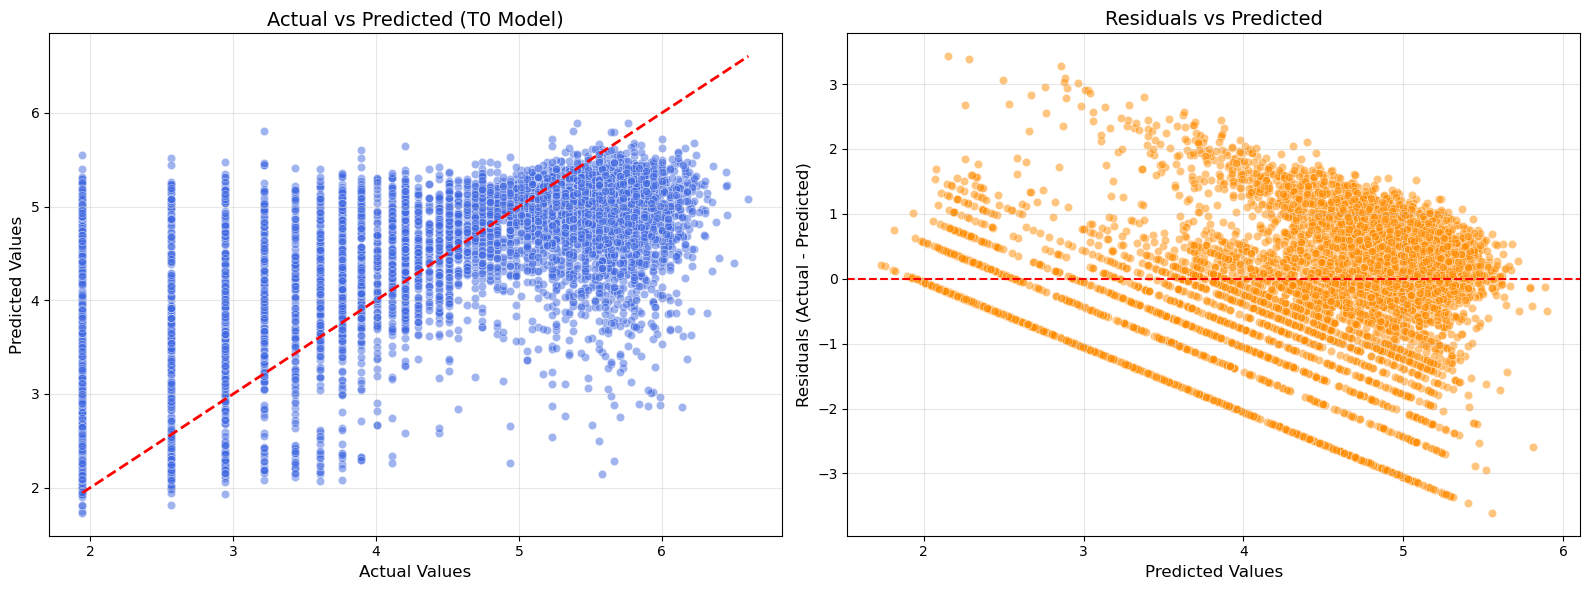

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 예측값 생성
y_pred = model_reg.predict(X_test)

# 2. 잔차(Residual) 계산
residuals = y_test - y_pred

# 3. 그래프 영역 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [왼쪽 그래프: Actual vs Predicted 산점도] ---
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0], color='royalblue')
# 대각선 기준선 추가 (완벽한 예측선)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted (T0 Model)', fontsize=14)
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].grid(alpha=0.3)

# --- [오른쪽 그래프: Residuals (잔차) 분포도] ---
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[1], color='darkorange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residuals vs Predicted', fontsize=14)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. 지표의 의미 해석 (현재 상태)
RMSE (0.9237): 타겟이 로그값이므로, 실제 시간으로 환산하면 예측 오차가 꽤 존재한다는 뜻입니다.

R2 Score (0.5221): "절반은 맞히고 절반은 못 맞힌다"고 볼 수 있습니다. 나머지 48%는 아직 모델이 모르는 '무언가'에 의해 결정되고 있습니다.

2. 개선 전략 1: 24h 모델과의 비교 (가장 확실한 방법)
현재 사용하신 것은 T0(진입 시점) 데이터뿐입니다. 여기에 "진입 후 24시간 동안의 변화량"을 추가하면 R2 Score는 보통 0.7~0.8 이상으로 크게 뜁니다.

추가할 피처: view_growth_24h (24시간 조회수 성장률), 랭킹 변화 속도 등.

분석 결론: "초기 데이터(T0)만으로는 52% 설명 가능하지만, 24시간 추이를 지켜보면 75%까지 예측 정확도가 올라간다"는 식의 데이터 가치 비교가 이 프로젝트의 핵심 결론이 됩니다.

3. 개선 전략 2: 이상치(Outlier) 및 타겟 조정
그래프에서 보셨듯이 실제값은 매우 큰데 작게 예측된 샘플들이 점수를 깎아먹고 있을 가능성이 큽니다.

타겟 필터링: 트렌딩 기간이 너무 짧거나(예: 6시간 미만) 너무 긴 극단적인 케이스를 일부 제거하고 학습하면 지표가 좋아집니다.

로그 변환 재확인: trending_duration에 로그를 취하셨는데, 혹시 +1을 하고 취하셨는지(np.log1p) 확인해 보세요. 0에 가까운 값들 때문에 오차가 커질 수 있습니다.

4. 개선 전략 3: 하이퍼파라미터 튜닝
LightGBM의 설정을 조금 더 세밀하게 조정해 볼 수 있습니다.

num_leaves: 트리의 복잡도를 조절합니다. (예: 31 -> 50)

min_data_in_leaf: 과적합을 방지합니다.

learning_rate: 0.03에서 0.01로 낮추고 n_estimators를 늘리면 더 정교하게 학습합니다.

5. 개선 전략 4: 피처 엔지니어링 추가
카테고리별 평균: 해당 영상이 속한 카테고리의 평균 지속 시간을 피처로 넣으면 모델이 '기본 점수'를 깔고 시작할 수 있습니다.

상호작용 변수: T0_view_log * entry_rank_log 처럼 두 변수를 곱한 새로운 변수가 의외로 강력한 힌트가 되기도 합니다.

# T0 분류

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier # Regressor가 아닌 Classifier 사용
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. 요일 사이클 변환
df = data.copy()
df['weekday_sin'] = np.sin(2 * np.pi * df['published_weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['published_weekday'] / 7)

# 2. 피처 선택 (조합 A: View + Engagement Ratio)
features_T0 = [
    'entry_rank_log', 'T0_view_log', 'T0_engagement_ratio_log', 
    'latency_to_trend_log', 'pretrend_view_velocity_log',
    'weekday_sin', 'weekday_cos', 'hour_sin', 'hour_cos',
    'saturation_index_30d_mean_prev'
]

# 3. 데이터 구성
X = pd.get_dummies(df[features_T0 + ['category_group']], columns=['category_group'])
y = df['long_label_48h'] # 분류용 타겟 (True/False 또는 1/0)

# 4. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

[LightGBM] [Info] Number of positive: 18817, number of negative: 9154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000649 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1538
[LightGBM] [Info] Number of data points in the train set: 27971, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.672732 -> initscore=0.720570
[LightGBM] [Info] Start training from score 0.720570
Training until validation scores don't improve for 50 rounds
[20]	valid_0's binary_logloss: 0.491823
[40]	valid_0's binary_logloss: 0.445618
[60]	valid_0's binary_logloss: 0.427142
[80]	valid_0's binary_logloss: 0.419032
[100]	valid_0's binary_logloss: 0.414711
[120]	valid_0's binary_logloss: 0.412753
[140]	valid_0's binary_logloss: 0.411841
[160]	valid_0's binary_logloss: 0.411071
[180]	valid_0's binary_logloss: 0.410529
[200]	valid_0's binary_logloss: 0.409769
[220]	valid_0's binary_logloss: 0.40926
[2

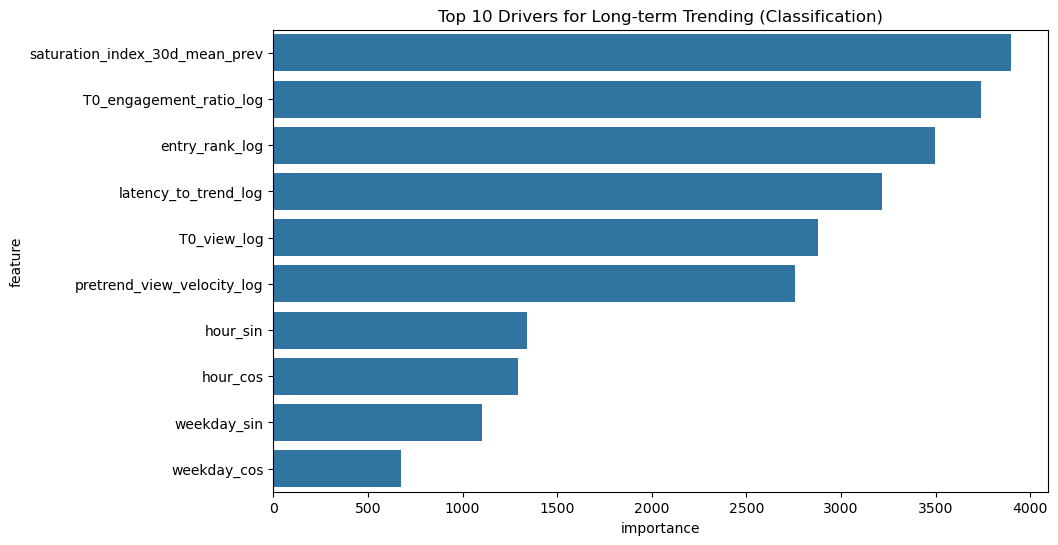

In [13]:
import lightgbm as lgb

# 모델 선언
model_clf = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    random_state=42,
    is_unbalance=True # 클래스 불균형이 있다면 도움이 됨
)

# 학습 진행
model_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='binary_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=20)
    ]
)

y_pred = model_clf.predict(X_test)
y_prob = model_clf.predict_proba(X_test)[:, 1] # ROC-AUC 계산용 확률값

print("--- [Classification Report] ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(10))
plt.title('Top 10 Drivers for Long-term Trending (Classification)')
plt.show()

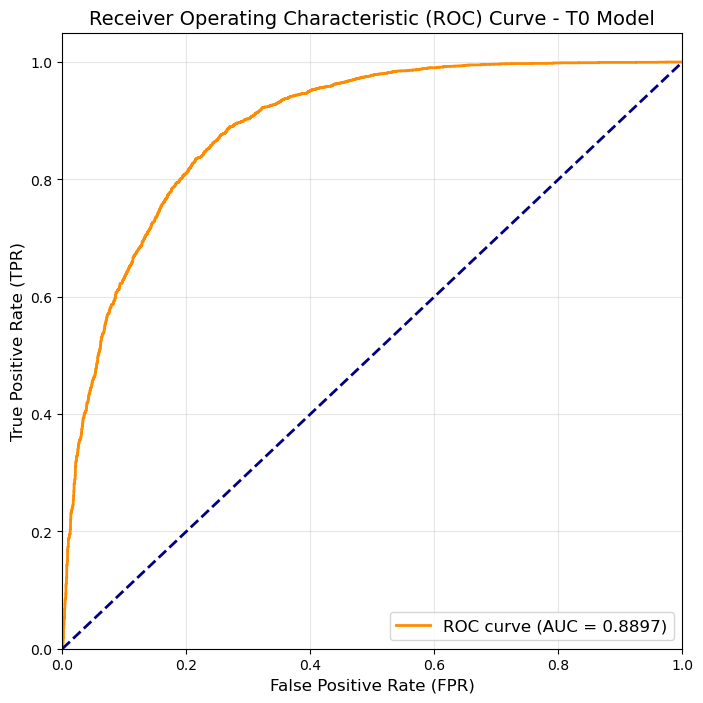

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 테스트 데이터에 대한 예측 확률 계산 (양성 클래스 확률)
y_pred_proba = model_clf.predict_proba(X_test)[:, 1]

# 2. FPR, TPR, 임계값(Threshold) 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. AUC(Area Under the Curve) 계산
roc_auc = auc(fpr, tpr)

# 4. 시각화
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 대각선 기준선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - T0 Model', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

1. 다수 클래스(단기 지속)로 인한 편향 방지유튜브 트렌딩 데이터에서는 단기 지속 영상이 장기 지속 영상보다 훨씬 많을 가능성이 높습니다.아무런 조치를 하지 않으면, 모델은 "대부분의 영상은 단기 지속된다"고 찍는 것만으로도 80~90%의 정확도를 얻을 수 있어 모든 영상을 단기 지속으로 예측하는 편향(Bias)이 생깁니다.불균형 조정 옵션을 켜면, 소수 클래스(장기 지속 영상)의 오차에 더 큰 페널티를 부여하여 모델이 장기 지속 영상의 특징(예: 높은 참여도, 빠른 유입 속도 등)을 제대로 학습하게 만듭니다.2. 비용 민감 학습 (Cost-Sensitive Learning)클래스 불균형 조정은 소수 클래스의 오분류 비용을 높이는 효과가 있습니다.$$\text{Loss} = \text{손실 함수} \times \text{가중치}$$단기 지속 영상을 틀렸을 때의 페널티: 작음장기 지속 영상을 단기 지속으로 틀렸을 때의 페널티: 큼이러한 가중치 조정을 통해 모델은 장기 지속 영상의 패턴을 놓치지 않으려고 더 집중하게 됩니다.3. 결정 경계(Decision Boundary)의 올바른 조정조정 전: 다수 클래스(단기) 쪽에 치우쳐 결정 경계가 형성되어, 장기 지속 영상도 단기 지속으로 분류해 버립니다.조정 후: 결정 경계가 중앙으로 이동하거나 장기 지속 클래스 쪽으로 확장되어, 두 클래스를 균형 있게 분리하게 됩니다.4. 실무적 관점 (비즈니스 임팩트)우리가 이 모델을 만드는 목적은 "어떤 영상이 48시간 이상 오래갈 것인가?"를 찾아내는 것입니다.장기 지속 영상을 놓치는 것(False Negative)은 큰 기회비용 손실을 의미합니다.클래스 불균형을 보정해주면 재현율(Recall)이 높아져 잠재력 있는 대박 영상을 놓칠 확률을 크게 줄여줍니다.